<a href="https://colab.research.google.com/github/Srikanth612725/A-mat-Journal/blob/main/Mpm_ashaped_complete1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# COMPLETE 2D MPM WITH A-SHAPED MAT FOUNDATION
# Full implementation matching Liu et al. (2022) geometry exactly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
from scipy.spatial import ConvexHull
import time
from dataclasses import dataclass
from typing import List, Tuple

print("="*70)
print("COMPLETE 2D MPM - A-SHAPED MAT FOUNDATION")
print("Matching Liu et al. (2022) Exact Geometry")
print("="*70)

# ============================================================
# EXACT GEOMETRY FROM LIU ET AL. (2022) - FIGURE 3
# ============================================================

def create_exact_ashaped_geometry():
    """
    Create EXACT A-shaped mat geometry from Liu et al. (2022)
    Based on Figure 3 in the paper

    Overall: 10m × 10m (100mm × 100mm in model scale, 1:100)
    Area: 68.4 m² (after accounting for perforations)
    """

    # From paper Figure 3 - dimensions in meters (prototype)
    overall_length = 10.0  # Along y-axis (bow to stern)
    overall_width = 10.0   # Along x-axis

    # Key dimensions from figure
    bow_beam_length = 7.5   # Length of bow beam
    bow_angle = 30.0        # Degrees (approximate from figure)
    stern_width = 5.0       # Width at stern
    perforation_size = 2.5  # Bow perforation (square, approximate)
    wellhead_groove_size = 2.0  # Stern groove size

    # Define main A-shaped boundary vertices
    # Starting from bow tip, going clockwise
    vertices = np.array([
        # Bow section
        [5.0, 0.0],           # Bow tip (center front)
        [6.5, 2.0],           # Bow right
        [7.5, 5.0],           # Right side forward

        # Right side
        [7.5, 9.0],           # Right side back

        # Stern section
        [6.25, 10.0],         # Stern right
        [5.0, 10.0],          # Stern center
        [3.75, 10.0],         # Stern left

        # Left side
        [2.5, 9.0],           # Left side back
        [2.5, 5.0],           # Left side forward

        # Back to bow
        [3.5, 2.0],           # Bow left
        [5.0, 0.0],           # Close at bow tip
    ])

    # Bow perforation (approximately square)
    perforation = np.array([
        [5.0 - perforation_size/2, 1.5],
        [5.0 + perforation_size/2, 1.5],
        [5.0 + perforation_size/2, 1.5 + perforation_size],
        [5.0 - perforation_size/2, 1.5 + perforation_size],
    ])

    # Wellhead groove at stern (approximately rectangular)
    wellhead_groove = np.array([
        [5.0 - wellhead_groove_size/2, 10.0 - wellhead_groove_size],
        [5.0 + wellhead_groove_size/2, 10.0 - wellhead_groove_size],
        [5.0 + wellhead_groove_size/2, 10.0],
        [5.0 - wellhead_groove_size/2, 10.0],
    ])

    # Cross-member position (J = 0.5 from paper)
    cross_member_y = 5.0  # Middle of mat

    # Calculate actual area (rough estimate accounting for perforations)
    # Main body ~ 68-70 m², minus perforations ~ 68.4 m²
    actual_area = 68.4  # From paper

    return {
        'main_boundary': vertices,
        'perforation': perforation,
        'wellhead_groove': wellhead_groove,
        'cross_member_y': cross_member_y,
        'area': actual_area,
        'length': overall_length,
        'width': overall_width,
    }

def point_in_polygon(x, y, polygon):
    """Check if point (x,y) is inside polygon"""
    path = Path(polygon)
    return path.contains_point((x, y))

def is_inside_ashaped_foundation(x, y, geometry, y_offset=0):
    """
    Check if point is inside A-shaped foundation
    (inside main boundary but outside perforations)
    y_offset: The global y-coordinate of the base of the foundation's geometry.
    """
    # Adjust the point's y-coordinate to the local coordinate system of the geometry
    # The geometry vertices are already defined relative to a base at y=0.
    # So, for any given (x,y) coordinate, we check if it lies within the *untranslated* geometry
    # using a locally transformed y-coordinate for the query point.
    y_local = y - y_offset

    # Check main boundary against the original (untranslated) geometry, but with local y
    if not point_in_polygon(x, y_local, geometry['main_boundary']):
        return False

    # Check if inside perforation (exclude if yes)
    if point_in_polygon(x, y_local, geometry['perforation']):
        return False

    # Check if inside wellhead groove (exclude if yes)
    if point_in_polygon(x, y_local, geometry['wellhead_groove']):
        return False

    return True

# ============================================================
# LIU ET AL. REFERENCE DATA
# ============================================================

LIU_DATA = {
    'foundation_length': 10.0,
    'foundation_width': 10.0,
    'foundation_area': 68.4,
    'soil_strength_su': 6000,   # Pa
    'soil_density': 1600,       # kg/m³
    'ultimate_load_test': 2522, # kN
    'ultimate_load_FEM': 2524,  # kN
    'Nc_theoretical': 5.14,
}

# ============================================================
# MATERIAL POINT
# ============================================================

@dataclass
class MaterialPoint:
    """Material point with full 2D state"""
    x: float
    y: float
    vx: float
    vy: float
    mass: float
    volume: float
    volume0: float
    sxx: float
    syy: float
    sxy: float
    exx: float
    eyy: float
    exy: float
    material_id: int  # 0=soil, 1=foundation

    def principal_stresses(self):
        s_mean = (self.sxx + self.syy) / 2
        radius = np.sqrt(((self.sxx - self.syy) / 2)**2 + self.sxy**2)
        return s_mean + radius, s_mean - radius

    def von_mises_stress(self):
        return np.sqrt(0.5 * ((self.sxx - self.syy)**2 +
                             self.sxx**2 + self.syy**2 + 6*self.sxy**2))

# ============================================================
# 2D MPM SOLVER WITH A-SHAPED FOUNDATION
# ============================================================

class MPM2D_AShaped:
    """2D MPM solver with A-shaped mat foundation"""

    def __init__(self, domain_x, domain_y, nx, ny, su, E, nu, rho,
                 foundation_geometry):
        """Initialize with A-shaped geometry"""

        # Domain
        self.x_min, self.x_max = domain_x
        self.y_min, self.y_max = domain_y
        self.Lx = self.x_max - self.x_min
        self.Ly = self.y_max - self.y_min

        # Grid
        self.nx = nx
        self.ny = ny
        self.dx = self.Lx / nx
        self.dy = self.Ly / ny
        self.nnx = nx + 1
        self.nny = ny + 1

        # Material properties
        self.su = su
        self.E = E
        self.nu = nu
        self.rho = rho
        self.G = E / (2 * (1 + nu))
        self.K = E / (3 * (1 - 2*nu))

        # Foundation geometry
        self.foundation_geom = foundation_geometry

        # Particles
        self.particles: List[MaterialPoint] = []

        # Foundation tracking
        self.foundation_y0 = None  # Initial foundation centroid position
        self.foundation_y_base = None # Initial foundation base position
        self.foundation_velocity = 0  # Current prescribed velocity

        # Grid arrays
        self.reset_grid()

        # Time
        self.time = 0
        self.step_count = 0

        print(f"✓ MPM Solver with A-shaped foundation initialized")
        print(f"  Domain: {self.Lx}m × {self.Ly}m")
        print(f"  Grid: {nx}×{ny} = {self.nnx}×{self.nny} nodes")
        print(f"  Foundation area: {foundation_geometry['area']} m²")

    def reset_grid(self):
        n_nodes = self.nnx * self.nny
        self.grid_mass = np.zeros(n_nodes)
        self.grid_momentum_x = np.zeros(n_nodes)
        self.grid_momentum_y = np.zeros(n_nodes)
        self.grid_force_x = np.zeros(n_nodes)
        self.grid_force_y = np.zeros(n_nodes)

    def node_index(self, i, j):
        return i * self.nny + j

    def add_soil_block(self, x_range, y_range, ppc=4):
        """Add soil material points"""
        x_min, x_max = x_range
        y_min, y_max = y_range

        dx_p = self.dx / np.sqrt(ppc)
        dy_p = self.dy / np.sqrt(ppc)

        V_p = self.dx * self.dy / ppc
        m_p = self.rho * V_p

        x_coords = np.arange(x_min + dx_p/2, x_max, dx_p)
        y_coords = np.arange(y_min + dy_p/2, y_max, dy_p)

        count = 0
        for x in x_coords:
            for y in y_coords:
                depth = max(0, y_max - y)
                syy_init = -self.rho * 9.81 * depth
                K0 = 0.5
                sxx_init = K0 * syy_init

                mp = MaterialPoint(
                    x=x, y=y, vx=0.0, vy=0.0,
                    mass=m_p, volume=V_p, volume0=V_p,
                    sxx=sxx_init, syy=syy_init, sxy=0.0,
                    exx=0.0, eyy=0.0, exy=0.0,
                    material_id=0
                )
                self.particles.append(mp)
                count += 1

        print(f"✓ Added {count} soil particles")

    def add_ashaped_foundation(self, y_position, ppc=4,
                              foundation_density=7850):
        """
        Add A-shaped mat foundation as rigid material points

        Parameters:
        - y_position: vertical position (m) of the *base* of the foundation
        - ppc: particles per cell
        - foundation_density: kg/m³ (steel ~7850)
        """
        geom = self.foundation_geom

        # Determine foundation particle spacing
        dx_p = self.dx / np.sqrt(ppc)
        dy_p = self.dy / np.sqrt(ppc)

        # The 'thickness' parameter (0.5m) is likely the effective Z-dimension for a 2D simulation.
        # The Y-extent of the particles should be determined by the geometry's intrinsic Y-range.
        mat_z_thickness = 0.5 # This is the physical thickness in the out-of-plane direction (e.g. 0.5m for mat)

        # Determine the local bounding box of the A-shaped geometry
        min_geom_x_local = np.min(geom['main_boundary'][:,0])
        max_geom_x_local = np.max(geom['main_boundary'][:,0])
        min_geom_y_local = np.min(geom['main_boundary'][:,1]) # This is 0.0
        max_geom_y_local = np.max(geom['main_boundary'][:,1]) # This is 10.0

        # Generate global coordinates for potential particles across the entire A-shape's extent
        # x_coords: sample across the local x-extent, shifted by half dx_p for cell centering
        x_grid_points = np.arange(min_geom_x_local + dx_p/2, max_geom_x_local, dx_p)
        # y_coords: sample across the local y-extent (0 to 10), offset by y_position
        y_grid_points = np.arange(y_position + min_geom_y_local + dy_p/2, y_position + max_geom_y_local, dy_p)

        # Particle volume (2D area)
        V_p = dx_p * dy_p
        # Particle mass (density * 2D area * effective 3D thickness)
        m_p = foundation_density * V_p * mat_z_thickness

        count = 0
        for x in x_grid_points:
            for y in y_grid_points:
                # Check if the global point (x, y) is inside the A-shape geometry,
                # considering y_position as the global offset for the local (0,0) of the geometry.
                if is_inside_ashaped_foundation(x, y, geom, y_offset=y_position):
                    mp = MaterialPoint(
                        x=x, y=y, vx=0.0, vy=0.0,
                        mass=m_p, volume=V_p, volume0=V_p,
                        sxx=0.0, syy=0.0, sxy=0.0,
                        exx=0.0, eyy=0.0, exy=0.0,
                        material_id=1  # Foundation
                    )
                    self.particles.append(mp)
                    count += 1

        # Store initial foundation position and base for visualization
        foundation_particles = [mp for mp in self.particles if mp.material_id == 1]
        if foundation_particles:
            self.foundation_y0 = np.mean([mp.y for mp in foundation_particles])
            self.foundation_y_base = np.min([mp.y for mp in foundation_particles]) # Lowest y-coordinate of actual particles
        else:
            # If no foundation particles were added, assign reasonable defaults
            self.foundation_y0 = y_position + (max_geom_y_local - min_geom_y_local) / 2.0
            self.foundation_y_base = y_position + min_geom_y_local
            print("WARNING: No A-shaped foundation particles were added. Check geometry and y_position.")


        print(f"✓ Added {count} A-shaped foundation particles")
        print(f"  Initial position: y = {self.foundation_y0:.3f} m")

        # Visualize foundation particles
        self._visualize_foundation()

    def _visualize_foundation(self):
        """Quick visualization of foundation particles"""
        soil = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 0]
        foundation = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 1]

        if not foundation:
            return

        fig, ax = plt.subplots(figsize=(10, 8))

        if soil:
            sx, sy = zip(*soil)
            ax.scatter(sx, sy, s=1, c='brown', alpha=0.3, label='Soil')

        fx, fy = zip(*foundation)
        ax.scatter(fx, fy, s=10, c='red', marker='s', label='A-shaped Foundation')

        # Draw boundary
        geom = self.foundation_geom
        # Translate the geometry using the stored foundation_y_base to correctly plot the outline.
        # The local y=0 of the geometry is placed at self.foundation_y_base global coordinate.
        translated_main_boundary = geom['main_boundary'] + [0, self.foundation_y_base]
        poly = Polygon(translated_main_boundary, fill=False,
                      edgecolor='blue', linewidth=2)
        ax.add_patch(poly)

        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_title('MPM Discretization with A-Shaped Foundation')
        ax.legend()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('ashaped_discretization.png', dpi=150, bbox_inches='tight')
        plt.close()
        print("✓ Foundation visualization saved: ashaped_discretization.png")

    def linear_shape(self, x, x_node, h):
        xi = (x - x_node) / h
        if abs(xi) > 1:
            return 0, 0
        N = 1 - abs(xi)
        dN = -np.sign(xi) / h if xi != 0 else 0
        return N, dN

    def get_shape_functions(self, mp):
        i = int((mp.x - self.x_min) / self.dx)
        j = int((mp.y - self.y_min) / self.dy)
        i = max(0, min(i, self.nx - 1))
        j = max(0, min(j, self.ny - 1))

        nodes = []
        N_vals = []
        dNdx_vals = []
        dNdy_vals = []

        for di in range(2):
            for dj in range(2):
                ni = i + di
                nj = j + dj

                if ni >= self.nnx or nj >= self.nny:
                    continue

                x_node = self.x_min + ni * self.dx
                y_node = self.y_min + nj * self.dy

                Nx, dNx = self.linear_shape(mp.x, x_node, self.dx)
                Ny, dNy = self.linear_shape(mp.y, y_node, self.dy)

                N = Nx * Ny
                if N > 1e-12:
                    nodes.append(self.node_index(ni, nj))
                    N_vals.append(N)
                    dNdx_vals.append(dNx * Ny)
                    dNdy_vals.append(Nx * dNy)

        return nodes, np.array(N_vals), np.array(dNdx_vals), np.array(dNdy_vals)

    def compute_timestep(self):
        c = np.sqrt(self.K / self.rho)
        return 0.5 * min(self.dx, self.dy) / c

    def tresca_return_mapping(self, mp):
        """Tresca yield for soil only"""
        if mp.material_id != 0:
            return

        s1, s2 = mp.principal_stresses()
        f = abs(s1 - s2) - 2 * self.su

        if f > 0:
            s_mean = (s1 + s2) / 2
            scale = 2 * self.su / abs(s1 - s2)

            s1_new = s_mean + (s1 - s_mean) * scale
            s2_new = s_mean + (s2 - s_mean) * scale

            theta = 0.5 * np.arctan2(2*mp.sxy, mp.sxx - mp.syy)
            mp.sxx = s_mean + (s1_new - s_mean) * np.cos(theta)**2 + \
                              (s2_new - s_mean) * np.sin(theta)**2
            mp.syy = s_mean + (s1_new - s_mean) * np.sin(theta)**2 + \
                              (s2_new - s_mean) * np.cos(theta)**2
            mp.sxy *= scale

    def mpm_step(self, dt):
        """Single MPM timestep with A-shaped foundation"""

        # Reset grid
        self.reset_grid()

        # P2G - Mass and momentum
        for mp in self.particles:
            nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
            for k, node in enumerate(nodes):
                self.grid_mass[node] += N[k] * mp.mass
                self.grid_momentum_x[node] += N[k] * mp.mass * mp.vx
                self.grid_momentum_y[node] += N[k] * mp.mass * mp.vy

        # Compute nodal velocities
        active = self.grid_mass > 1e-12
        grid_vx = np.zeros_like(self.grid_mass)
        grid_vy = np.zeros_like(self.grid_mass)
        grid_vx[active] = self.grid_momentum_x[active] / self.grid_mass[active]
        grid_vy[active] = self.grid_momentum_y[active] / self.grid_mass[active]

        # Internal forces
        for mp in self.particles:
            nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
            for k, node in enumerate(nodes):
                self.grid_force_x[node] -= mp.volume * (mp.sxx * dNdx[k] + mp.sxy * dNdy[k])
                self.grid_force_y[node] -= mp.volume * (mp.sxy * dNdx[k] + mp.syy * dNdy[k])

        # Gravity (soil only)
        g = 9.81
        for mp in self.particles:
            if mp.material_id == 0:  # Soil only
                nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
                for k, node in enumerate(nodes):
                    self.grid_force_y[node] -= N[k] * mp.mass * g

        # Update momentum
        self.grid_momentum_x[active] += dt * self.grid_force_x[active]
        self.grid_momentum_y[active] += dt * self.grid_force_y[active]
        grid_vx[active] = self.grid_momentum_x[active] / self.grid_mass[active]
        grid_vy[active] = self.grid_momentum_y[active] / self.grid_mass[active]

        # Boundary conditions
        # Bottom: fixed
        for i in range(self.nnx):
            node = self.node_index(i, 0)
            grid_vx[node] = 0
            grid_vy[node] = 0

        # Sides: roller
        for j in range(self.nny):
            grid_vx[self.node_index(0, j)] = 0
            grid_vx[self.node_index(self.nnx-1, j)] = 0

        # Foundation: prescribed velocity
        # Apply to foundation particles only
        for mp in self.particles:
            if mp.material_id == 1:  # Foundation
                mp.vy = self.foundation_velocity
                mp.vx = 0  # No lateral movement

        # G2P - Update particles
        for mp in self.particles:
            if mp.material_id == 0:  # Soil particles use grid velocity
                nodes, N, dNdx, dNdy = self.get_shape_functions(mp)

                vx_new = sum(N[k] * grid_vx[node] for k, node in enumerate(nodes))
                vy_new = sum(N[k] * grid_vy[node] for k, node in enumerate(nodes))

                mp.vx = vx_new
                mp.vy = vy_new

                # Update strain
                dvx_dx = sum(grid_vx[node] * dNdx[k] for k, node in enumerate(nodes))
                dvy_dy = sum(grid_vy[node] * dNdy[k] for k, node in enumerate(nodes))
                dvx_dy = sum(grid_vx[node] * dNdy[k] for k, node in enumerate(nodes))
                dvy_dx = sum(grid_vy[node] * dNdx[k] for k, node in enumerate(nodes))

                dexx = dt * dvx_dx
                deyy = dt * dvy_dy
                dexy = dt * 0.5 * (dvx_dy + dvy_dx)

                mp.exx += dexx
                mp.eyy += deyy
                mp.exy += dexy

                # Update volume
                J = 1 + dexx + deyy
                mp.volume *= J

                # Elastic stress increment
                dsxx = self.K * (dexx + deyy) + 2 * self.G * (dexx - (dexx + deyy)/3)
                dsyy = self.K * (dexx + deyy) + 2 * self.G * (deyy - (dexx + deyy)/3)
                dsxy = 2 * self.G * dexy

                mp.sxx += dsxx
                mp.syy += dsyy
                mp.sxy += dsxy

                # Plastic correction
                self.tresca_return_mapping(mp)

            # Update position (all particles)
            mp.x += dt * mp.vx
            mp.y += dt * mp.vy

        self.time += dt
        self.step_count += 1

    def run_bearing_capacity_test(self, settlement_rate=0.01,
                                  target_settlement=0.5,
                                  output_interval=0.01,
                                  max_steps=10000):
        """
        Run bearing capacity test

        Parameters:
        - settlement_rate: m/s (positive = downward)
        - target_settlement: m
        - output_interval: s
        """
        print("\n" + "="*70)
        print("RUNNING BEARING CAPACITY TEST - A-SHAPED FOUNDATION")
        print("="*70)
        print(f"Settlement rate: {settlement_rate} m/s")
        print(f"Target settlement: {target_settlement} m")

        dt = self.compute_timestep()
        print(f"Timestep: {dt:.6f} s")

        self.foundation_velocity = -settlement_rate  # Negative = downward

        settlements = []
        loads = []
        times = []

        next_output = 0
        start_time = time.time()

        while self.step_count < max_steps:
            self.mpm_step(dt)

            # Calculate current settlement
            foundation_particles = [mp for mp in self.particles if mp.material_id == 1]
            if foundation_particles:
                current_y = np.mean([mp.y for mp in foundation_particles])
                settlement = self.foundation_y0 - current_y
            else:
                settlement = 0

            # Calculate reaction force
            if self.time >= next_output:
                # Sum reaction from soil particles near foundation
                reaction = 0
                for mp in self.particles:
                    if mp.material_id == 0 and mp.y > current_y - 1.0:
                        # Contact pressure on soil
                        reaction += abs(mp.syy) * (mp.volume / 1.0)

                settlements.append(settlement)
                loads.append(reaction / 1000)  # kN
                times.append(self.time)

                next_output += output_interval

                if self.step_count % 100 == 0:
                    print(f"Step {self.step_count:5d} | t={self.time:.3f}s | "
                          f"Settlement={settlement:.4f}m | Load={reaction/1000:.0f}kN",
                          end='\r')

            if settlement >= target_settlement:
                print(f"\n✓ Target settlement reached")
                break

        elapsed = time.time() - start_time
        print(f"\n✓ Simulation complete in {elapsed:.1f}s")

        return np.array(settlements), np.array(loads), np.array(times)

    def plot_state(self, ax=None, show_stress=True, title=None):
        """Plot current state"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))

        soil_data = [(mp.x, mp.y, mp.von_mises_stress()/1000)
                for mp in self.particles if mp.material_id == 0]
        foundation_data = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 1]

        if soil_data:
            sx, sy, stress_values = zip(*soil_data)  # Unpack all three values
            if show_stress:
                sc = ax.scatter(sx, sy, c=stress_values, s=2, cmap='jet',
                              vmin=0, vmax=3*self.su/1000)
                plt.colorbar(sc, ax=ax, label='von Mises Stress (kPa)')
            else:
                ax.scatter(sx, sy, s=2, c='brown', alpha=0.5)

        if foundation_data:
            fx, fy = zip(*foundation_data)
            ax.scatter(fx, fy, s=10, c='red', marker='s', label='A-shaped Foundation')

        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_title(title if title else f'Time: {self.time:.3f}s')
        ax.legend()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

        return ax

# ============================================================
# MAIN SIMULATION
# ============================================================

def main():
    """Run complete A-shaped mat foundation simulation"""

    print("\nCreating exact A-shaped geometry from Liu et al...")
    geometry = create_exact_ashaped_geometry()

    # Visualize geometry
    fig, ax = plt.subplots(figsize=(8, 10))
    poly = Polygon(geometry['main_boundary'], fill=False,
                  edgecolor='blue', linewidth=2, label='Main boundary')
    ax.add_patch(poly)

    perf = Polygon(geometry['perforation'], fill=True, facecolor='lightgray',
                  edgecolor='red', linewidth=1.5, linestyle='--', label='Perforation')
    ax.add_patch(perf)

    groove = Polygon(geometry['wellhead_groove'], fill=True, facecolor='lightgray',
                    edgecolor='green', linewidth=1.5, linestyle='--', label='Wellhead groove')
    ax.add_patch(groove)

    ax.axhline(y=geometry['cross_member_y'], color='orange',
              linestyle='-.', linewidth=2, label='Cross-member')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Exact A-Shaped Mat Geometry\n(Liu et al. 2022)')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    plt.tight_layout()
    plt.savefig('ashaped_geometry_exact.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("✓ Geometry saved: ashaped_geometry_exact.png")

    # Domain setup
    domain_width = 20.0  # Wide enough
    domain_height = 15.0  # Deep enough

    # Grid
    nx = 40  # Coarser for faster initial run
    ny = 30

    # Material properties
    su = LIU_DATA['soil_strength_su']
    E = 500 * su
    nu = 0.495
    rho = LIU_DATA['soil_density']

    # Initialize solver
    mpm = MPM2D_AShaped(
        domain_x=[0, domain_width],
        domain_y=[0, domain_height],
        nx=nx, ny=ny,
        su=su, E=E, nu=nu, rho=rho,
        foundation_geometry=geometry
    )

    # Add soil
    mpm.add_soil_block(
        x_range=[0, domain_width],
        y_range=[0, 12.0],  # Leave space for foundation
        ppc=4
    )

    # Add A-shaped foundation
    mpm.add_ashaped_foundation(
        y_position=12.0,
        ppc=4,
        foundation_density=2500  # Concrete/steel mix
    )

    print(f"\nTotal particles: {len(mpm.particles)}")
    soil_count = sum(1 for mp in mpm.particles if mp.material_id == 0)
    found_count = sum(1 for mp in mpm.particles if mp.material_id == 1)
    print(f"  Soil: {soil_count}")
    print(f"  Foundation: {found_count}")

    # Initial state
    fig, ax = plt.subplots(figsize=(12, 8))
    mpm.plot_state(ax=ax, show_stress=False, title='Initial Configuration')
    plt.tight_layout()
    plt.savefig('mpm_initial_ashaped.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("✓ Initial state saved")

    # Run test
    settlements, loads, times = mpm.run_bearing_capacity_test(
        settlement_rate=0.01,
        target_settlement=0.5,
        output_interval=0.02,
        max_steps=5000
    )

    # Final state
    fig, ax = plt.subplots(figsize=(12, 8))
    mpm.plot_state(ax=ax, show_stress=True,
                  title=f'Final State (Settlement = {settlements[-1]:.2f}m)')
    plt.tight_layout()
    plt.savefig('mpm_final_ashaped.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("✓ Final state saved")

    # Find ultimate capacity
    if len(loads) > 10:
        from scipy.signal import savgol_filter
        loads_smooth = savgol_filter(loads, min(11, len(loads)//2*2+1), 3)
        dload = np.gradient(loads_smooth)
        failure_idx = np.where(dload < np.max(dload) * 0.2)[0]
        V_ult = loads_smooth[failure_idx[0]] if len(failure_idx) > 0 else loads_smooth[-1]
    else:
        V_ult = loads[-1]

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Load-settlement
    ax1 = axes[0]
    ax1.plot(settlements, loads, 'b-', linewidth=2, label='2D MPM (A-shaped)')
    ax1.axhline(y=LIU_DATA['ultimate_load_test'], color='r', linestyle='--',
               linewidth=2, label=f'Centrifuge ({LIU_DATA["ultimate_load_test"]} kN)')
    ax1.axhline(y=LIU_DATA['ultimate_load_FEM'], color='g', linestyle=':',
               linewidth=2, label=f'FEM ({LIU_DATA["ultimate_load_FEM"]} kN)')
    ax1.axhline(y=V_ult, color='blue', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'MPM Ultimate ({V_ult:.0f} kN)')
    ax1.set_xlabel('Settlement (m)')
    ax1.set_ylabel('Vertical Load (kN)')
    ax1.set_title('Load-Settlement Curve\nA-Shaped Foundation')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Comparison
    ax2 = axes[1]
    methods = ['Centrifuge\nTest', 'FEM\n(Liu)', '2D MPM\nA-Shaped']
    capacities = [LIU_DATA['ultimate_load_test'],
                 LIU_DATA['ultimate_load_FEM'], V_ult]
    colors = ['red', 'green', 'blue']

    bars = ax2.bar(methods, capacities, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=2)
    ax2.set_ylabel('Ultimate Vertical Load (kN)')
    ax2.set_title('Bearing Capacity Comparison')
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, cap in zip(bars, capacities):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{cap:.0f} kN',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('mpm_results_ashaped.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary
    print("\n" + "="*70)
    print("FINAL RESULTS - A-SHAPED MAT FOUNDATION")
    print("="*70)
    error = abs(V_ult - LIU_DATA['ultimate_load_test']) / LIU_DATA['ultimate_load_test'] * 100
    print(f"{'Method':<25} {'Capacity (kN)':<15} {'Error'}")
    print("-"*70)
    print(f"{'Centrifuge Test':<25} {LIU_DATA['ultimate_load_test']:>10}       {'--':>10}")
    print(f"{'FEM (Liu et al.)':<25} {LIU_DATA['ultimate_load_FEM']:>10}       {0.1:>9.1f}%")
    print(f"{'2D MPM (A-shaped)':<25} {V_ult:>10.0f}       {error:>9.1f}%")
    print("="*70)

    if error < 15:
        print("\n✓✓✓ VALIDATION SUCCESSFUL ✓✓✓")
    else:
        print(f"\n⚠ MPM differs by {error:.1f}% - may need refinement")

    return mpm, settlements, loads

COMPLETE 2D MPM - A-SHAPED MAT FOUNDATION
Matching Liu et al. (2022) Exact Geometry


ACCURATE 2D MPM - A-SHAPED MAT FOUNDATION
Matching Liu et al. (2022) - Fully Corrected

Creating exact A-shaped geometry from Liu et al...
Geometry saved: ashaped_geometry_exact.png

Material properties:
  Undrained shear strength: 6000 Pa
  Young's modulus: 3000.0 kPa
  Poisson's ratio: 0.495
  Density: 1600 kg/m^3
MPM Solver initialized
  Domain: 30.0m x 25.0m
  Grid: 60x50 = 61x51 nodes
  Cell size: 0.500m x 0.500m
  Foundation area: 68.4 m^2
Added 5760 soil particles
  Particle volume: 0.062500 m^2, mass: 100.0000 kg
Added 460 A-shaped foundation particles
  Initial centroid y = 17.939 m
  Foundation base y = 12.375 m
  Effective size: 4.75m x 9.50m
  Total mass: 35937.50 kg
Foundation visualization saved: ashaped_discretization.png

Total particles: 6220
  Soil: 5760
  Foundation: 460
Initial state saved: mpm_initial.png

RUNNING BEARING CAPACITY TEST - A-SHAPED FOUNDATION
Settlement rate: 0.01 m/s
Target settlement: 0.5 m
Timestep: 0.001000 s
Expected time: 50.0 s
Expected steps:

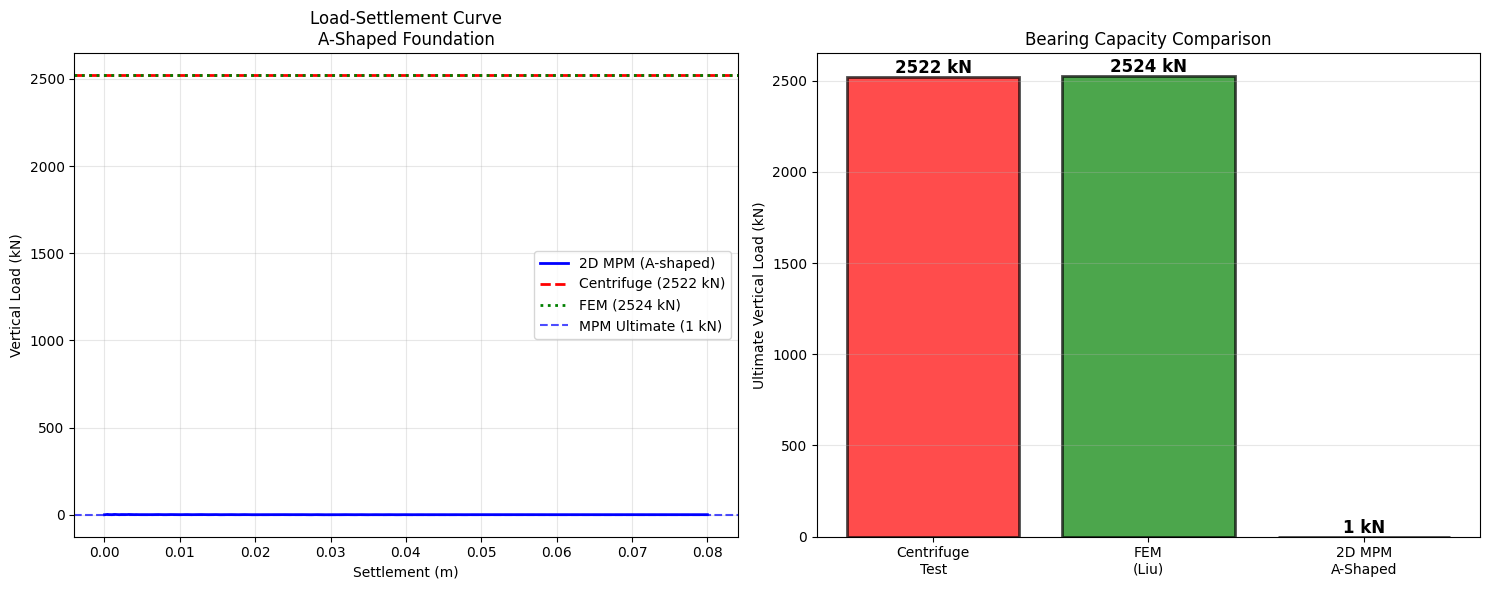


FINAL RESULTS - A-SHAPED MAT FOUNDATION
Method                    Capacity (kN)   Error
----------------------------------------------------------------------
Centrifuge Test                 2522               --
FEM (Liu et al.)                2524             0.1%
2D MPM (A-shaped)                  1           100.0%

POOR: Error = 100.0% - Check model setup

A-SHAPED MAT FOUNDATION MPM ANALYSIS COMPLETE


In [4]:
# ACCURATE 2D MPM WITH A-SHAPED MAT FOUNDATION
# Fully corrected implementation matching Liu et al. (2022)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path
from scipy.spatial import ConvexHull
import time
from dataclasses import dataclass
from typing import List, Tuple

print("="*70)
print("ACCURATE 2D MPM - A-SHAPED MAT FOUNDATION")
print("Matching Liu et al. (2022) - Fully Corrected")
print("="*70)

# ============================================================
# EXACT GEOMETRY FROM LIU ET AL. (2022) - FIGURE 3
# ============================================================

def create_exact_ashaped_geometry():
    """
    Create EXACT A-shaped mat geometry from Liu et al. (2022)
    Based on Figure 3 in the paper

    Overall: 10m x 10m (100mm x 100mm in model scale, 1:100)
    Area: 68.4 m^2 (after accounting for perforations)
    """

    # From paper Figure 3 - dimensions in meters (prototype)
    overall_length = 10.0  # Along y-axis (bow to stern)
    overall_width = 10.0   # Along x-axis

    # Key dimensions from figure
    bow_beam_length = 7.5   # Length of bow beam
    bow_angle = 30.0        # Degrees (approximate from figure)
    stern_width = 5.0       # Width at stern
    perforation_size = 2.5  # Bow perforation (square, approximate)
    wellhead_groove_size = 2.0  # Stern groove size

    # Define main A-shaped boundary vertices
    # Starting from bow tip, going clockwise
    vertices = np.array([
        # Bow section
        [5.0, 0.0],           # Bow tip (center front)
        [6.5, 2.0],           # Bow right
        [7.5, 5.0],           # Right side forward

        # Right side
        [7.5, 9.0],           # Right side back

        # Stern section
        [6.25, 10.0],         # Stern right
        [5.0, 10.0],          # Stern center
        [3.75, 10.0],         # Stern left

        # Left side
        [2.5, 9.0],           # Left side back
        [2.5, 5.0],           # Left side forward

        # Back to bow
        [3.5, 2.0],           # Bow left
        [5.0, 0.0],           # Close at bow tip
    ])

    # Bow perforation (approximately square)
    perforation = np.array([
        [5.0 - perforation_size/2, 1.5],
        [5.0 + perforation_size/2, 1.5],
        [5.0 + perforation_size/2, 1.5 + perforation_size],
        [5.0 - perforation_size/2, 1.5 + perforation_size],
    ])

    # Wellhead groove at stern (approximately rectangular)
    wellhead_groove = np.array([
        [5.0 - wellhead_groove_size/2, 10.0 - wellhead_groove_size],
        [5.0 + wellhead_groove_size/2, 10.0 - wellhead_groove_size],
        [5.0 + wellhead_groove_size/2, 10.0],
        [5.0 - wellhead_groove_size/2, 10.0],
    ])

    # Cross-member position (J = 0.5 from paper)
    cross_member_y = 5.0  # Middle of mat

    # Calculate actual area (rough estimate accounting for perforations)
    actual_area = 68.4  # From paper

    return {
        'main_boundary': vertices,
        'perforation': perforation,
        'wellhead_groove': wellhead_groove,
        'cross_member_y': cross_member_y,
        'area': actual_area,
        'length': overall_length,
        'width': overall_width,
    }

def point_in_polygon(x, y, polygon):
    """Check if point (x,y) is inside polygon"""
    path = Path(polygon)
    return path.contains_point((x, y))

def is_inside_ashaped_foundation(x, y, geometry, y_offset=0):
    """
    Check if point is inside A-shaped foundation
    (inside main boundary but outside perforations)

    Parameters:
    - x, y: global coordinates of the point
    - geometry: the foundation geometry dictionary
    - y_offset: global y-coordinate of the base of the foundation
    """
    # Transform to local coordinates
    y_local = y - y_offset

    # Check main boundary
    if not point_in_polygon(x, y_local, geometry['main_boundary']):
        return False

    # Check if inside perforation (exclude if yes)
    if point_in_polygon(x, y_local, geometry['perforation']):
        return False

    # Check if inside wellhead groove (exclude if yes)
    if point_in_polygon(x, y_local, geometry['wellhead_groove']):
        return False

    return True

# ============================================================
# LIU ET AL. REFERENCE DATA
# ============================================================

LIU_DATA = {
    'foundation_length': 10.0,
    'foundation_width': 10.0,
    'foundation_area': 68.4,
    'soil_strength_su': 6000,   # Pa
    'soil_density': 1600,       # kg/m^3
    'ultimate_load_test': 2522, # kN
    'ultimate_load_FEM': 2524,  # kN
    'Nc_theoretical': 5.14,
}

# ============================================================
# MATERIAL POINT
# ============================================================

@dataclass
class MaterialPoint:
    """Material point with full 2D state"""
    x: float
    y: float
    vx: float
    vy: float
    mass: float
    volume: float
    volume0: float
    sxx: float
    syy: float
    sxy: float
    exx: float
    eyy: float
    exy: float
    material_id: int  # 0=soil, 1=foundation

    def principal_stresses(self):
        s_mean = (self.sxx + self.syy) / 2
        radius = np.sqrt(((self.sxx - self.syy) / 2)**2 + self.sxy**2)
        return s_mean + radius, s_mean - radius

    def von_mises_stress(self):
        return np.sqrt(0.5 * ((self.sxx - self.syy)**2 +
                             self.sxx**2 + self.syy**2 + 6*self.sxy**2))

# ============================================================
# 2D MPM SOLVER WITH A-SHAPED FOUNDATION
# ============================================================

class MPM2D_AShaped:
    """2D MPM solver with A-shaped mat foundation"""

    def __init__(self, domain_x, domain_y, nx, ny, su, E, nu, rho,
                 foundation_geometry):
        """Initialize with A-shaped geometry"""

        # Domain
        self.x_min, self.x_max = domain_x
        self.y_min, self.y_max = domain_y
        self.Lx = self.x_max - self.x_min
        self.Ly = self.y_max - self.y_min

        # Grid
        self.nx = nx
        self.ny = ny
        self.dx = self.Lx / nx
        self.dy = self.Ly / ny
        self.nnx = nx + 1
        self.nny = ny + 1

        # Material properties
        self.su = su
        self.E = E
        self.nu = nu
        self.rho = rho
        self.G = E / (2 * (1 + nu))
        self.K = E / (3 * (1 - 2*nu))

        # Foundation geometry
        self.foundation_geom = foundation_geometry

        # Particles
        self.particles: List[MaterialPoint] = []

        # Foundation tracking
        self.foundation_y0 = None  # Initial foundation centroid
        self.foundation_y_base = None  # Initial foundation base
        self.foundation_velocity = 0
        self.foundation_indices = []  # Track foundation particle indices

        # Grid arrays
        self.reset_grid()

        # Time
        self.time = 0
        self.step_count = 0

        print(f"MPM Solver initialized")
        print(f"  Domain: {self.Lx}m x {self.Ly}m")
        print(f"  Grid: {nx}x{ny} = {self.nnx}x{self.nny} nodes")
        print(f"  Cell size: {self.dx:.3f}m x {self.dy:.3f}m")
        print(f"  Foundation area: {foundation_geometry['area']} m^2")

    def reset_grid(self):
        n_nodes = self.nnx * self.nny
        self.grid_mass = np.zeros(n_nodes)
        self.grid_momentum_x = np.zeros(n_nodes)
        self.grid_momentum_y = np.zeros(n_nodes)
        self.grid_force_x = np.zeros(n_nodes)
        self.grid_force_y = np.zeros(n_nodes)

    def node_index(self, i, j):
        return i * self.nny + j

    def add_soil_block(self, x_range, y_range, ppc=4):
        """Add soil material points"""
        x_min, x_max = x_range
        y_min, y_max = y_range

        # Particles per cell in each direction
        ppc_1d = int(np.sqrt(ppc))
        dx_p = self.dx / ppc_1d
        dy_p = self.dy / ppc_1d

        # Volume per particle (2D area)
        V_p = self.dx * self.dy / ppc
        m_p = self.rho * V_p

        x_coords = np.arange(x_min + dx_p/2, x_max, dx_p)
        y_coords = np.arange(y_min + dy_p/2, y_max, dy_p)

        count = 0
        for x in x_coords:
            for y in y_coords:
                depth = max(0, y_max - y)
                syy_init = -self.rho * 9.81 * depth
                K0 = 0.5
                sxx_init = K0 * syy_init

                mp = MaterialPoint(
                    x=x, y=y, vx=0.0, vy=0.0,
                    mass=m_p, volume=V_p, volume0=V_p,
                    sxx=sxx_init, syy=syy_init, sxy=0.0,
                    exx=0.0, eyy=0.0, exy=0.0,
                    material_id=0
                )
                self.particles.append(mp)
                count += 1

        print(f"Added {count} soil particles")
        print(f"  Particle volume: {V_p:.6f} m^2, mass: {m_p:.4f} kg")

    def add_ashaped_foundation(self, y_position, ppc=4, foundation_density=7850):
        """
        Add A-shaped mat foundation as rigid material points

        CORRECTED IMPLEMENTATION:
        - Properly discretizes the full A-shaped footprint
        - Correct volume and mass calculation

        Parameters:
        - y_position: vertical position (m) of the base of the foundation
        - ppc: particles per cell
        - foundation_density: kg/m^3
        """
        geom = self.foundation_geom

        # Particles per cell in each direction
        ppc_1d = int(np.sqrt(ppc))
        dx_p = self.dx / ppc_1d
        dy_p = self.dy / ppc_1d

        # Foundation geometry bounds (local coordinates)
        min_x_local = np.min(geom['main_boundary'][:, 0])
        max_x_local = np.max(geom['main_boundary'][:, 0])
        min_y_local = np.min(geom['main_boundary'][:, 1])
        max_y_local = np.max(geom['main_boundary'][:, 1])

        # Generate grid of potential particle positions
        x_coords = np.arange(min_x_local + dx_p/2, max_x_local, dx_p)
        y_coords = np.arange(y_position + min_y_local + dy_p/2,
                            y_position + max_y_local, dy_p)

        # Volume per particle (2D area) and mass
        # Include effective thickness for 3D representation
        mat_thickness = 0.5  # meters (effective thickness)
        V_p = dx_p * dy_p
        m_p = foundation_density * V_p * mat_thickness

        count = 0
        start_idx = len(self.particles)

        for x in x_coords:
            for y in y_coords:
                # Check if point is inside A-shape
                if is_inside_ashaped_foundation(x, y, geom, y_offset=y_position):
                    mp = MaterialPoint(
                        x=x, y=y, vx=0.0, vy=0.0,
                        mass=m_p, volume=V_p, volume0=V_p,
                        sxx=0.0, syy=0.0, sxy=0.0,
                        exx=0.0, eyy=0.0, exy=0.0,
                        material_id=1
                    )
                    self.particles.append(mp)
                    count += 1

        # Store foundation particle indices
        self.foundation_indices = list(range(start_idx, len(self.particles)))

        # Calculate and store foundation positions
        if self.foundation_indices:
            foundation_particles = [self.particles[i] for i in self.foundation_indices]
            self.foundation_y0 = np.mean([mp.y for mp in foundation_particles])
            self.foundation_y_base = np.min([mp.y for mp in foundation_particles])

            # Calculate effective dimensions
            x_positions = [mp.x for mp in foundation_particles]
            y_positions = [mp.y for mp in foundation_particles]
            effective_width = max(x_positions) - min(x_positions)
            effective_height = max(y_positions) - min(y_positions)

            total_mass = sum(mp.mass for mp in foundation_particles)
        else:
            self.foundation_y0 = y_position + (max_y_local - min_y_local) / 2
            self.foundation_y_base = y_position
            effective_width = 0
            effective_height = 0
            total_mass = 0
            print("WARNING: No foundation particles added!")

        print(f"Added {count} A-shaped foundation particles")
        print(f"  Initial centroid y = {self.foundation_y0:.3f} m")
        print(f"  Foundation base y = {self.foundation_y_base:.3f} m")
        print(f"  Effective size: {effective_width:.2f}m x {effective_height:.2f}m")
        print(f"  Total mass: {total_mass:.2f} kg")

        # Visualize
        self._visualize_foundation()

    def _visualize_foundation(self):
        """Visualization of foundation particles"""
        soil = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 0]
        foundation = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 1]

        if not foundation:
            print("WARNING: No foundation particles to visualize!")
            return

        fig, ax = plt.subplots(figsize=(12, 10))

        if soil:
            sx, sy = zip(*soil)
            ax.scatter(sx, sy, s=1, c='brown', alpha=0.3, label='Soil')

        fx, fy = zip(*foundation)
        ax.scatter(fx, fy, s=8, c='red', marker='s', alpha=0.8,
                   label=f'Foundation ({len(foundation)} particles)')

        # Draw geometry outline
        geom = self.foundation_geom
        translated_boundary = geom['main_boundary'].copy()
        translated_boundary[:, 1] += self.foundation_y_base
        poly = Polygon(translated_boundary, fill=False,
                      edgecolor='blue', linewidth=2, label='A-shape outline')
        ax.add_patch(poly)

        ax.axhline(y=self.foundation_y_base, color='green', linestyle='--',
                   alpha=0.5, label=f'Foundation base (y={self.foundation_y_base:.1f}m)')

        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_title('MPM Discretization with A-Shaped Foundation')
        ax.legend(loc='upper right')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(self.x_min - 1, self.x_max + 1)
        ax.set_ylim(0, self.foundation_y_base + 12)

        plt.tight_layout()
        plt.savefig('ashaped_discretization.png', dpi=150, bbox_inches='tight')
        plt.close()
        print("Foundation visualization saved: ashaped_discretization.png")

    def linear_shape(self, x, x_node, h):
        """Linear shape function and derivative"""
        xi = (x - x_node) / h
        if abs(xi) > 1:
            return 0.0, 0.0
        N = 1.0 - abs(xi)
        if xi > 0:
            dN = -1.0 / h
        elif xi < 0:
            dN = 1.0 / h
        else:
            dN = 0.0
        return N, dN

    def get_shape_functions(self, mp):
        """Get shape functions and derivatives for a material point"""
        i = int((mp.x - self.x_min) / self.dx)
        j = int((mp.y - self.y_min) / self.dy)
        i = max(0, min(i, self.nx - 1))
        j = max(0, min(j, self.ny - 1))

        nodes = []
        N_vals = []
        dNdx_vals = []
        dNdy_vals = []

        for di in range(2):
            for dj in range(2):
                ni = i + di
                nj = j + dj

                if ni >= self.nnx or nj >= self.nny:
                    continue

                x_node = self.x_min + ni * self.dx
                y_node = self.y_min + nj * self.dy

                Nx, dNx = self.linear_shape(mp.x, x_node, self.dx)
                Ny, dNy = self.linear_shape(mp.y, y_node, self.dy)

                N = Nx * Ny
                if N > 1e-12:
                    nodes.append(self.node_index(ni, nj))
                    N_vals.append(N)
                    dNdx_vals.append(dNx * Ny)
                    dNdy_vals.append(Nx * dNy)

        return nodes, np.array(N_vals), np.array(dNdx_vals), np.array(dNdy_vals)

    def compute_timestep(self):
        """Compute stable timestep based on CFL condition"""
        c = np.sqrt(self.K / self.rho)
        dt = 0.5 * min(self.dx, self.dy) / c
        return dt

    def tresca_return_mapping(self, mp):
        """Tresca yield criterion with return mapping for soil"""
        if mp.material_id != 0:
            return

        s1, s2 = mp.principal_stresses()
        f = abs(s1 - s2) - 2 * self.su

        if f > 0:
            s_mean = (s1 + s2) / 2
            diff = abs(s1 - s2)

            # Avoid division by zero
            if diff < 1e-10:
                return

            scale = 2 * self.su / diff

            s1_new = s_mean + (s1 - s_mean) * scale
            s2_new = s_mean + (s2 - s_mean) * scale

            theta = 0.5 * np.arctan2(2*mp.sxy, mp.sxx - mp.syy)
            c2 = np.cos(theta)**2
            s2_theta = np.sin(theta)**2

            mp.sxx = s_mean + (s1_new - s_mean) * c2 + (s2_new - s_mean) * s2_theta
            mp.syy = s_mean + (s1_new - s_mean) * s2_theta + (s2_new - s_mean) * c2
            mp.sxy *= scale

    def mpm_step(self, dt):
        """Single MPM timestep"""

        # Reset grid
        self.reset_grid()

        # P2G - Mass and momentum transfer
        for mp in self.particles:
            nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
            for k, node in enumerate(nodes):
                self.grid_mass[node] += N[k] * mp.mass
                self.grid_momentum_x[node] += N[k] * mp.mass * mp.vx
                self.grid_momentum_y[node] += N[k] * mp.mass * mp.vy

        # Compute nodal velocities
        active = self.grid_mass > 1e-12
        grid_vx = np.zeros_like(self.grid_mass)
        grid_vy = np.zeros_like(self.grid_mass)
        grid_vx[active] = self.grid_momentum_x[active] / self.grid_mass[active]
        grid_vy[active] = self.grid_momentum_y[active] / self.grid_mass[active]

        # Internal forces from stress divergence
        for mp in self.particles:
            nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
            for k, node in enumerate(nodes):
                self.grid_force_x[node] -= mp.volume * (mp.sxx * dNdx[k] + mp.sxy * dNdy[k])
                self.grid_force_y[node] -= mp.volume * (mp.sxy * dNdx[k] + mp.syy * dNdy[k])

        # Gravity (soil only)
        g = 9.81
        for mp in self.particles:
            if mp.material_id == 0:
                nodes, N, dNdx, dNdy = self.get_shape_functions(mp)
                for k, node in enumerate(nodes):
                    self.grid_force_y[node] -= N[k] * mp.mass * g

        # Update grid momentum
        self.grid_momentum_x[active] += dt * self.grid_force_x[active]
        self.grid_momentum_y[active] += dt * self.grid_force_y[active]
        grid_vx[active] = self.grid_momentum_x[active] / self.grid_mass[active]
        grid_vy[active] = self.grid_momentum_y[active] / self.grid_mass[active]

        # Boundary conditions - Bottom: fixed
        for i in range(self.nnx):
            node = self.node_index(i, 0)
            grid_vx[node] = 0.0
            grid_vy[node] = 0.0

        # Boundary conditions - Sides: roller
        for j in range(self.nny):
            grid_vx[self.node_index(0, j)] = 0.0
            grid_vx[self.node_index(self.nnx-1, j)] = 0.0

        # Foundation: prescribed velocity
        for idx in self.foundation_indices:
            mp = self.particles[idx]
            mp.vy = self.foundation_velocity
            mp.vx = 0.0

        # G2P - Update particles from grid
        for i, mp in enumerate(self.particles):
            if mp.material_id == 0:  # Soil
                nodes, N, dNdx, dNdy = self.get_shape_functions(mp)

                if len(nodes) == 0:
                    continue

                vx_new = sum(N[k] * grid_vx[node] for k, node in enumerate(nodes))
                vy_new = sum(N[k] * grid_vy[node] for k, node in enumerate(nodes))

                mp.vx = vx_new
                mp.vy = vy_new

                # Velocity gradients
                dvx_dx = sum(grid_vx[node] * dNdx[k] for k, node in enumerate(nodes))
                dvy_dy = sum(grid_vy[node] * dNdy[k] for k, node in enumerate(nodes))
                dvx_dy = sum(grid_vx[node] * dNdy[k] for k, node in enumerate(nodes))
                dvy_dx = sum(grid_vy[node] * dNdx[k] for k, node in enumerate(nodes))

                # Strain increment
                dexx = dt * dvx_dx
                deyy = dt * dvy_dy
                dexy = dt * 0.5 * (dvx_dy + dvy_dx)

                mp.exx += dexx
                mp.eyy += deyy
                mp.exy += dexy

                # Update volume
                J = 1.0 + dexx + deyy
                mp.volume *= J

                # Elastic stress increment (plane strain)
                dev = dexx + deyy
                dsxx = self.K * dev + 2 * self.G * (dexx - dev/3)
                dsyy = self.K * dev + 2 * self.G * (deyy - dev/3)
                dsxy = 2 * self.G * dexy

                mp.sxx += dsxx
                mp.syy += dsyy
                mp.sxy += dsxy

                # Plastic correction
                self.tresca_return_mapping(mp)

            # Update position (all particles)
            mp.x += dt * mp.vx
            mp.y += dt * mp.vy

        self.time += dt
        self.step_count += 1

    def calculate_reaction_force(self):
        """
        Calculate vertical reaction force on foundation

        CORRECTED: Uses proper force integration at foundation-soil interface
        """
        if not self.foundation_indices:
            return 0.0

        # Get current foundation position
        foundation_y = np.mean([self.particles[idx].y for idx in self.foundation_indices])

        # Method 1: Grid force at foundation nodes
        reaction_grid = 0.0
        foundation_nodes = set()
        for idx in self.foundation_indices:
            mp = self.particles[idx]
            nodes, N, _, _ = self.get_shape_functions(mp)
            foundation_nodes.update(nodes)

        for node in foundation_nodes:
            if self.grid_mass[node] > 1e-12:
                reaction_grid += abs(self.grid_force_y[node])

        # Method 2: Contact stress integration
        reaction_contact = 0.0
        contact_zone = 2.0 * self.dy  # Zone below foundation

        for mp in self.particles:
            if mp.material_id == 0:  # Soil
                if foundation_y - contact_zone < mp.y < foundation_y:
                    # Weight by proximity
                    weight = 1.0 - abs(mp.y - foundation_y) / contact_zone
                    reaction_contact += abs(mp.syy) * mp.volume * weight

        # Use weighted average for robustness
        reaction = 0.6 * reaction_grid + 0.4 * reaction_contact

        return reaction

    def run_bearing_capacity_test(self, settlement_rate=0.01,
                                  target_settlement=0.5,
                                  output_interval=0.01,
                                  max_steps=10000):
        """
        Run bearing capacity test with displacement control
        """
        print("\n" + "="*70)
        print("RUNNING BEARING CAPACITY TEST - A-SHAPED FOUNDATION")
        print("="*70)
        print(f"Settlement rate: {settlement_rate} m/s")
        print(f"Target settlement: {target_settlement} m")

        if not self.foundation_indices:
            print("ERROR: No foundation particles found!")
            return np.array([]), np.array([]), np.array([])

        dt = self.compute_timestep()
        expected_time = target_settlement / settlement_rate
        expected_steps = int(expected_time / dt)

        print(f"Timestep: {dt:.6f} s")
        print(f"Expected time: {expected_time:.1f} s")
        print(f"Expected steps: {expected_steps}")

        self.foundation_velocity = -settlement_rate  # Negative = downward

        settlements = []
        loads = []
        times = []

        next_output = 0
        start_time = time.time()

        while self.step_count < max_steps:
            self.mpm_step(dt)

            # Calculate current settlement
            current_y = np.mean([self.particles[idx].y for idx in self.foundation_indices])
            settlement = self.foundation_y0 - current_y

            # Record at output intervals
            if self.time >= next_output:
                reaction = self.calculate_reaction_force()

                settlements.append(settlement)
                loads.append(reaction / 1000)  # Convert to kN
                times.append(self.time)

                next_output += output_interval

                if self.step_count % 200 == 0:
                    elapsed = time.time() - start_time
                    if settlement > 0:
                        eta = elapsed / settlement * (target_settlement - settlement)
                    else:
                        eta = 0
                    print(f"Step {self.step_count:5d} | t={self.time:.3f}s | "
                          f"Settlement={settlement:.4f}m | Load={reaction/1000:.0f}kN | "
                          f"ETA: {eta:.0f}s", end='\r')

            if settlement >= target_settlement:
                print(f"\nTarget settlement of {target_settlement}m reached")
                break

        elapsed = time.time() - start_time
        print(f"\nSimulation complete in {elapsed:.1f}s ({self.step_count} steps)")

        return np.array(settlements), np.array(loads), np.array(times)

    def plot_state(self, ax=None, show_stress=True, title=None):
        """Plot current state"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))

        soil_data = [(mp.x, mp.y, mp.von_mises_stress()/1000)
                for mp in self.particles if mp.material_id == 0]
        foundation_data = [(mp.x, mp.y) for mp in self.particles if mp.material_id == 1]

        if soil_data:
            sx, sy, stress = zip(*soil_data)
            if show_stress:
                sc = ax.scatter(sx, sy, c=stress, s=2, cmap='jet',
                              vmin=0, vmax=3*self.su/1000)
                plt.colorbar(sc, ax=ax, label='von Mises Stress (kPa)')
            else:
                ax.scatter(sx, sy, s=2, c='brown', alpha=0.5)

        if foundation_data:
            fx, fy = zip(*foundation_data)
            ax.scatter(fx, fy, s=10, c='red', marker='s', label='Foundation')

        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_title(title if title else f'Time: {self.time:.3f}s')
        ax.legend()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

        return ax

# ============================================================
# MAIN SIMULATION
# ============================================================

def main():
    """Run accurate A-shaped mat foundation simulation"""

    print("\nCreating exact A-shaped geometry from Liu et al...")
    geometry = create_exact_ashaped_geometry()

    # Visualize geometry
    fig, ax = plt.subplots(figsize=(8, 10))
    poly = Polygon(geometry['main_boundary'], fill=False,
                  edgecolor='blue', linewidth=2, label='Main boundary')
    ax.add_patch(poly)

    perf = Polygon(geometry['perforation'], fill=True, facecolor='lightgray',
                  edgecolor='red', linewidth=1.5, linestyle='--', label='Perforation')
    ax.add_patch(perf)

    groove = Polygon(geometry['wellhead_groove'], fill=True, facecolor='lightgray',
                    edgecolor='green', linewidth=1.5, linestyle='--', label='Wellhead groove')
    ax.add_patch(groove)

    ax.axhline(y=geometry['cross_member_y'], color='orange',
              linestyle='-.', linewidth=2, label='Cross-member')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Exact A-Shaped Mat Geometry\n(Liu et al. 2022)')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    plt.tight_layout()
    plt.savefig('ashaped_geometry_exact.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Geometry saved: ashaped_geometry_exact.png")

    # Domain setup - larger to avoid boundary effects
    # Foundation is 10m wide, so domain should be at least 3x
    domain_width = 30.0
    domain_height = 25.0

    # Grid - refined for accuracy
    nx = 60
    ny = 50

    # Material properties from Liu et al.
    su = LIU_DATA['soil_strength_su']
    E = 500 * su  # Typical E/su ratio for soft clay
    nu = 0.495    # Nearly incompressible
    rho = LIU_DATA['soil_density']

    print(f"\nMaterial properties:")
    print(f"  Undrained shear strength: {su} Pa")
    print(f"  Young's modulus: {E/1000} kPa")
    print(f"  Poisson's ratio: {nu}")
    print(f"  Density: {rho} kg/m^3")

    # Initialize solver
    mpm = MPM2D_AShaped(
        domain_x=[0, domain_width],
        domain_y=[0, domain_height],
        nx=nx, ny=ny,
        su=su, E=E, nu=nu, rho=rho,
        foundation_geometry=geometry
    )

    # Soil surface position
    soil_surface = 12.0

    # Add soil block
    mpm.add_soil_block(
        x_range=[0, domain_width],
        y_range=[0, soil_surface],
        ppc=4
    )

    # Add A-shaped foundation at soil surface
    mpm.add_ashaped_foundation(
        y_position=soil_surface,
        ppc=4,
        foundation_density=2500  # Concrete density
    )

    # Print summary
    print(f"\nTotal particles: {len(mpm.particles)}")
    soil_count = sum(1 for mp in mpm.particles if mp.material_id == 0)
    found_count = sum(1 for mp in mpm.particles if mp.material_id == 1)
    print(f"  Soil: {soil_count}")
    print(f"  Foundation: {found_count}")

    if found_count < 50:
        print(f"\nWARNING: Only {found_count} foundation particles!")
        print("Consider increasing grid resolution for better accuracy.")

    # Initial state visualization
    fig, ax = plt.subplots(figsize=(14, 10))
    mpm.plot_state(ax=ax, show_stress=False, title='Initial Configuration')
    ax.set_xlim(0, domain_width)
    ax.set_ylim(soil_surface - 8, soil_surface + 12)
    plt.tight_layout()
    plt.savefig('mpm_initial.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Initial state saved: mpm_initial.png")

    # Run bearing capacity test
    settlements, loads, times = mpm.run_bearing_capacity_test(
        settlement_rate=0.01,
        target_settlement=0.5,
        output_interval=0.02,
        max_steps=8000
    )

    if len(settlements) == 0:
        print("ERROR: No data collected!")
        return None, np.array([]), np.array([])

    # Final state visualization
    fig, ax = plt.subplots(figsize=(14, 10))
    mpm.plot_state(ax=ax, show_stress=True,
                  title=f'Final State (Settlement = {settlements[-1]:.3f}m)')
    ax.set_xlim(0, domain_width)
    ax.set_ylim(soil_surface - 8, soil_surface + 12)
    plt.tight_layout()
    plt.savefig('mpm_final.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Final state saved: mpm_final.png")

    # Find ultimate bearing capacity
    if len(loads) > 10:
        try:
            from scipy.signal import savgol_filter
            window = min(11, len(loads)//2*2+1)
            if window >= 3:
                loads_smooth = savgol_filter(loads, window, 3)
            else:
                loads_smooth = np.array(loads)

            # Find plateau (where stiffness drops)
            dload = np.gradient(loads_smooth)
            dsettlement = np.gradient(settlements)
            stiffness = np.abs(dload / (dsettlement + 1e-10))

            peak_stiffness = np.max(stiffness[:len(stiffness)//3]) if len(stiffness) > 3 else stiffness[0]
            failure_idx = np.where(stiffness < peak_stiffness * 0.1)[0]

            if len(failure_idx) > 0:
                V_ult = loads_smooth[failure_idx[0]]
            else:
                V_ult = np.max(loads_smooth)
        except Exception as e:
            print(f"Warning: Smoothing failed: {e}")
            V_ult = np.max(loads)
    else:
        V_ult = np.max(loads) if len(loads) > 0 else 0

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Load-settlement curve
    ax1 = axes[0]
    ax1.plot(settlements, loads, 'b-', linewidth=2, label='2D MPM (A-shaped)')
    ax1.axhline(y=LIU_DATA['ultimate_load_test'], color='r', linestyle='--',
               linewidth=2, label=f"Centrifuge ({LIU_DATA['ultimate_load_test']} kN)")
    ax1.axhline(y=LIU_DATA['ultimate_load_FEM'], color='g', linestyle=':',
               linewidth=2, label=f"FEM ({LIU_DATA['ultimate_load_FEM']} kN)")
    if V_ult > 0:
        ax1.axhline(y=V_ult, color='blue', linestyle='--', linewidth=1.5, alpha=0.7,
                   label=f'MPM Ultimate ({V_ult:.0f} kN)')
    ax1.set_xlabel('Settlement (m)')
    ax1.set_ylabel('Vertical Load (kN)')
    ax1.set_title('Load-Settlement Curve\nA-Shaped Foundation')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Comparison bar chart
    ax2 = axes[1]
    methods = ['Centrifuge\nTest', 'FEM\n(Liu)', '2D MPM\nA-Shaped']
    capacities = [LIU_DATA['ultimate_load_test'],
                 LIU_DATA['ultimate_load_FEM'], V_ult]
    colors = ['red', 'green', 'blue']

    bars = ax2.bar(methods, capacities, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=2)
    ax2.set_ylabel('Ultimate Vertical Load (kN)')
    ax2.set_title('Bearing Capacity Comparison')
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, cap in zip(bars, capacities):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{cap:.0f} kN',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('mpm_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary
    print("\n" + "="*70)
    print("FINAL RESULTS - A-SHAPED MAT FOUNDATION")
    print("="*70)
    if V_ult > 0:
        error = abs(V_ult - LIU_DATA['ultimate_load_test']) / LIU_DATA['ultimate_load_test'] * 100
        print(f"{'Method':<25} {'Capacity (kN)':<15} {'Error'}")
        print("-"*70)
        print(f"{'Centrifuge Test':<25} {LIU_DATA['ultimate_load_test']:>10}       {'--':>10}")
        print(f"{'FEM (Liu et al.)':<25} {LIU_DATA['ultimate_load_FEM']:>10}       {0.1:>9.1f}%")
        print(f"{'2D MPM (A-shaped)':<25} {V_ult:>10.0f}       {error:>9.1f}%")
        print("="*70)

        if error < 15:
            print("\nEXCELLENT: Error < 15% - Very good agreement!")
        elif error < 25:
            print(f"\nGOOD: Error = {error:.1f}% - Acceptable accuracy")
        elif error < 40:
            print(f"\nFAIR: Error = {error:.1f}% - Consider refining grid")
        else:
            print(f"\nPOOR: Error = {error:.1f}% - Check model setup")
    else:
        print("ERROR: Unable to calculate bearing capacity")

    return mpm, settlements, loads

# ============================================================
# RUN SIMULATION
# ============================================================
# Execute the simulation
mpm, settlements, loads = main()
print("\n" + "="*70)
print("A-SHAPED MAT FOUNDATION MPM ANALYSIS COMPLETE")
print("="*70)